In [1]:
from pathlib import Path

from spikeinterface.preprocessing import detect_bad_channels
import spikeinterface.full as si
from probeinterface.plotting import plot_probe
from probeinterface import Probe
import figpack.views as vv
# from hs_detection import HSDetection
from spikeinterface.preprocessing import get_motion_parameters_preset, get_motion_presets


import numpy as np
from matplotlib import pyplot as plt

(<matplotlib.collections.PolyCollection at 0x1f01bb151d0>,
 <matplotlib.collections.PolyCollection at 0x1f01bb15210>)

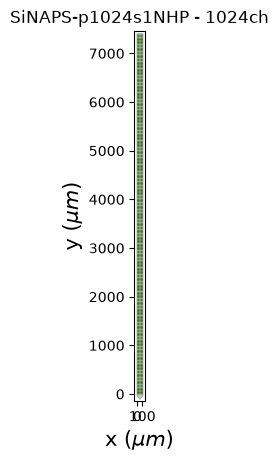

In [2]:
def get_SiNAPS_Probe():
    # Keep this hand-written geometry for now.
    # Reference metadata also exists at:
    #   session_dir / "SiNAPS_v_1_6_kilosortChanMap.prb"
    # That .prb file describes a 1024-channel, 4 column x 256 row, 30 um channel map.
    # This notebook's hand-written geometry uses 29 um, so confirm the intended geometry before replacing it.
    # a grid 256 rows x 4 columns, 30 um apart
    positions = 29 * np.mgrid[0:256, 0:4].reshape((2, -1))[::-1].T

    probe_2d = Probe(ndim=2, si_units='um', name='SiNAPS-p1024s1NHP')
    channel_indices = np.arange(1024)
    probe_2d.set_contacts(positions=positions, shapes='square', shape_params={'width': 14}, contact_ids=channel_indices)
    probe_2d.set_device_channel_indices(channel_indices)
    probe_2d.create_auto_shape(probe_type='tip')
    return probe_2d

probe = get_SiNAPS_Probe()
plot_probe(probe)

In [3]:
from spikeinterface.core import BinaryRecordingExtractor
# from probeinterface import get_probe

repo_root = Path(r"D:\SPIHackerthon\spikeinterface")
##session_dir = repo_root / "src" / "spikeinterface" / "Datasets" / "30Connell_0"
dat_path = "30Connell_0.dat"
prb_path = "SiNAPS_v_1_6_kilosortChanMap.prb"

# The .prb path is kept as reference metadata only; do not replace the hand-written probe geometry here.

recording = BinaryRecordingExtractor(
    file_paths=dat_path,
    sampling_frequency=20000.0,
    num_channels=1024,
    dtype="int16",
    gain_to_uV=5.85,
    offset_to_uV=1.5*100
)
recording.set_probe(probe)
print(recording)


BinaryRecordingExtractor: 1024 channels - 20.0kHz - 1 segments - 31,912,000 samples 
                          1,595.60s (26.59 minutes) - int16 dtype - 60.87 GiB
  file_paths: ['d:\\SPIHackerthon\\spikeinterface\\30Connell_0.dat']


In [4]:
recording = recording.astype('float32')

In [5]:
'''time_range = [0, 1]
channels = np.arange(0, 1000, 50)
# si.plot_traces(recording, channel_ids=channels, time_range=time_range,  figsize=(16, 2))
d = recording.get_traces(channel_ids=channels, start_frame=int(time_range[0] * recording.get_sampling_frequency()), end_frame=int(time_range[1] * recording.get_sampling_frequency()))
plt.figure(figsize=(16, 4))
for i in range(d.shape[1]):
    plt.plot(d[:,i] + i*50 )  # Offset each channel for better visibility
# plt.plot(d);'''

'time_range = [0, 1]\nchannels = np.arange(0, 1000, 50)\n# si.plot_traces(recording, channel_ids=channels, time_range=time_range,  figsize=(16, 2))\nd = recording.get_traces(channel_ids=channels, start_frame=int(time_range[0] * recording.get_sampling_frequency()), end_frame=int(time_range[1] * recording.get_sampling_frequency()))\nplt.figure(figsize=(16, 4))\nfor i in range(d.shape[1]):\n    plt.plot(d[:,i] + i*50 )  # Offset each channel for better visibility\n# plt.plot(d);'

In [6]:
method = 'coherence+psd'
bad_channel_ids, channel_labels = si.detect_bad_channels(recording, method=method, std_mad_threshold=3)#, dead_channel_threshold=-1)

In [7]:
'''short_recording = recording.frame_slice(0,200000)
short_recording.annotate(is_filtered=True)
from spikeinterface.preprocessing import detect_bad_channels
# for method in ['std','mad','coherence+psd','neighborhood_r2']:
#     bad_ch, labels = detect_bad_channels(short_recording, method=method, std_mad_threshold = 3)
#     print(f"Bad channels detected by {method}: {bad_ch}")
method = 'coherence+psd'
bad_ch, labels = detect_bad_channels(short_recording, method=method, std_mad_threshold = 3)'''

'short_recording = recording.frame_slice(0,200000)\nshort_recording.annotate(is_filtered=True)\nfrom spikeinterface.preprocessing import detect_bad_channels\n# for method in [\'std\',\'mad\',\'coherence+psd\',\'neighborhood_r2\']:\n#     bad_ch, labels = detect_bad_channels(short_recording, method=method, std_mad_threshold = 3)\n#     print(f"Bad channels detected by {method}: {bad_ch}")\nmethod = \'coherence+psd\'\nbad_ch, labels = detect_bad_channels(short_recording, method=method, std_mad_threshold = 3)'

In [8]:
recording_clean = recording.remove_channels(bad_channel_ids)

In [9]:
print("label counts:", dict(zip(*np.unique(channel_labels, return_counts=True))))
print("dead_channel_ids:", bad_channel_ids)
print("num dead:", len(bad_channel_ids))
print("original:", recording.get_num_channels())
print("clean:", recording_clean.get_num_channels())

label counts: {np.str_('dead'): np.int64(116), np.str_('good'): np.int64(827), np.str_('noise'): np.int64(79), np.str_('out'): np.int64(2)}
dead_channel_ids: [   3   20   43   47   51   52   58   60   61   66   67   72   76   80
   82   84   86   88  107  111  113  116  118  119  120  122  124  125
  130  131  136  140  146  148  149  150  171  175  178  179  184  186
  188  189  258  259  264  268  274  276  278  299  303  306  307  314
  316  317  322  323  328  342  344  363  367  371  376  378  380  381
  385  386  387  392  396  404  406  427  431  434  435  440  442  444
  450  451  456  458  460  466  468  491  506  508  509  514  515  520
  532  534  555  559  563  570  572  573  578  579  584  592  596  598
  600  613  615  619  623  627  634  636  637  639  704  705  706  707
  712  716  720  726  728  737  739  747  750  751  758  762  764  765
  770  771  776  780  781  782  783  790  811  815  819  828  829  830
  833  834  835  840  845  846  847  848  854  856  871  875 

std_threshold: 2.1457465
num dead channels: 144
dead_channel_ids: [117 119 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207
 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225
 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243
 244 245 246 247 248 249 250 251 252 253 254 255 445 447 452 454 468 470
 640 641 642 643 644 645 646 647 648 649 650 651 652 653 654 655 656 657
 658 659 660 661 662 663 664 665 666 667 668 669 670 671 672 673 674 675
 676 677 678 679 680 681 682 683 684 685 686 687 688 689 690 691 692 693
 694 695 696 697 698 699 700 701 702 703 737 739 777 779 848 850 968 970]


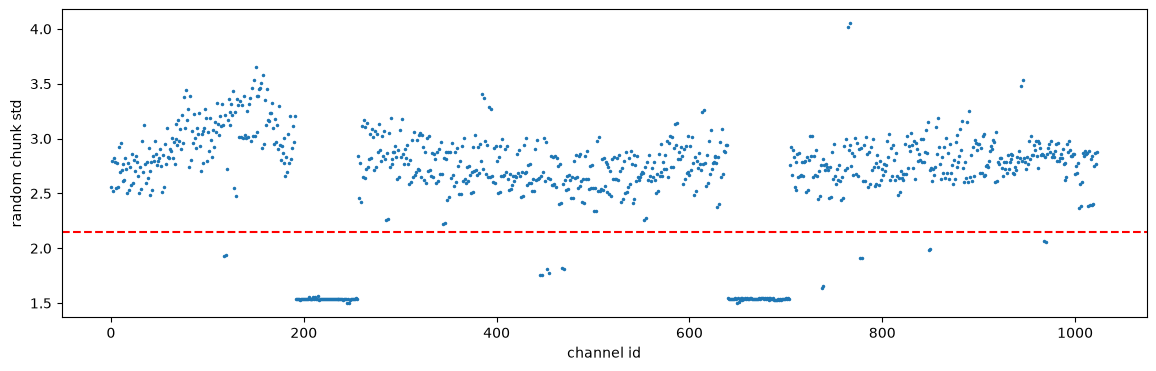

In [10]:
from spikeinterface.core import get_random_data_chunks

chunks = get_random_data_chunks(
    recording,
    num_chunks_per_segment=50,
    chunk_duration="500ms",
    return_in_uV=False,
    concatenated=True,
    seed=0,
)
channel_ids = np.asarray(recording.get_channel_ids())
stds = chunks.std(axis=0)

finite_mask = np.isfinite(stds)
sorted_stds = np.sort(stds[finite_mask])

# 自动找低 std dead-channel 簇和正常 channel 簇之间的最大 gap
lower_half = sorted_stds[sorted_stds <= np.percentile(sorted_stds, 50)]
gaps = np.diff(lower_half)
gap_index = np.argmax(gaps)
std_threshold = 0.5 * (lower_half[gap_index] + lower_half[gap_index + 1])

dead_mask = (~finite_mask) | (stds < std_threshold)
dead_channel_ids = channel_ids[dead_mask]

print("std_threshold:", std_threshold)
print("num dead channels:", len(dead_channel_ids))
print("dead_channel_ids:", dead_channel_ids)

plt.figure(figsize=(14, 4))
plt.plot(channel_ids, stds, ".", markersize=3)
plt.axhline(std_threshold, color="r", linestyle="--")
plt.xlabel("channel id")
plt.ylabel("random chunk std")
plt.show()

In [11]:
recording_clean = recording.remove_channels(dead_channel_ids)

print("original:", recording.get_num_channels())
print("clean:", recording_clean.get_num_channels())
print("removed:", recording.get_num_channels() - recording_clean.get_num_channels())
print("dead still present:", np.intersect1d(dead_channel_ids, recording_clean.get_channel_ids()))

original: 1024
clean: 880
removed: 144
dead still present: []


In [12]:
tr = recording_clean.get_traces(0, 0, 1000)

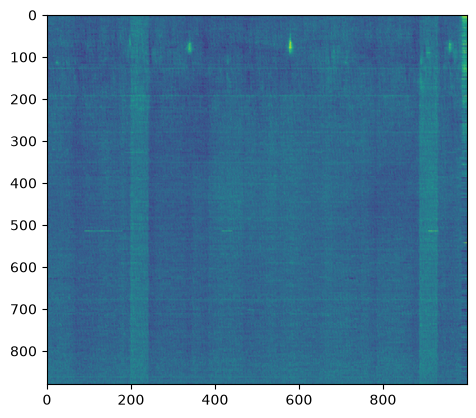

In [13]:
plt.imshow(tr.T)

In [ ]:
#local common median reference
recording_local_ref = si.common_reference(
    recording_clean,
    reference="local",
    operator="median",
    local_radius=(100, 200),
    min_local_neighbors=8,
    dtype="float32",
)

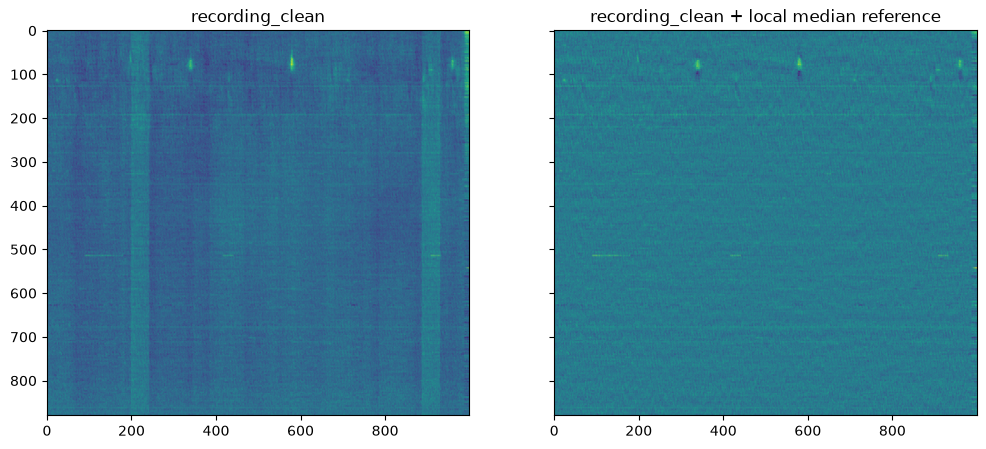

In [35]:
tr_before = recording_clean.get_traces(0, 0, 1000)
tr_after = recording_local_ref.get_traces(0, 0, 1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].imshow(tr_before.T, aspect="auto")
axes[0].set_title("recording_clean")

axes[1].imshow(tr_after.T, aspect="auto")
axes[1].set_title("recording_clean + local median reference")

plt.show()

In [ ]:
recording_cmr = si.common_reference(recording_clean, reference="global", operator="median")

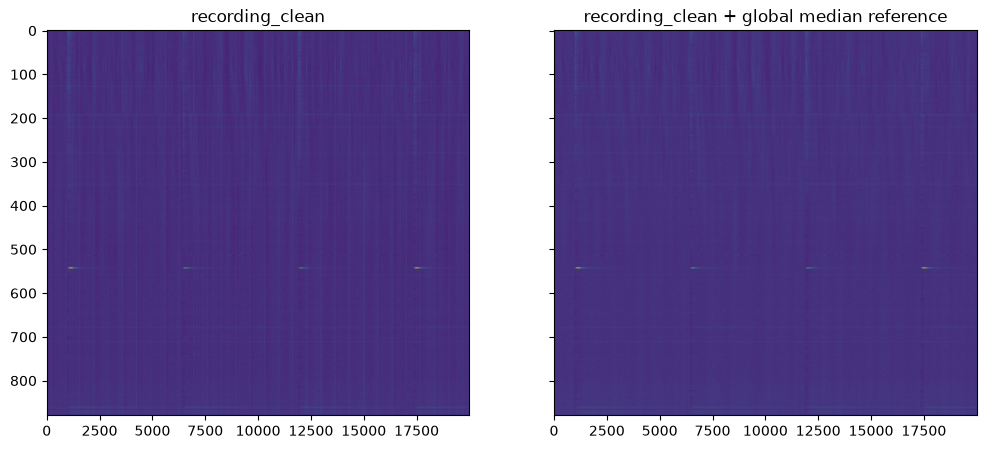

In [30]:
start_frame = 0
end_frame = 20000

tr_before = recording_clean.get_traces(start_frame=start_frame, end_frame=end_frame)
tr_after = recording_cmr.get_traces(start_frame=start_frame, end_frame=end_frame)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].imshow(tr_before.T, aspect="auto")
axes[0].set_title("recording_clean")

axes[1].imshow(tr_after.T, aspect="auto")
axes[1].set_title("recording_clean + global median reference")

plt.show()

In [27]:
# 1. temporal highpass/bandpass
recording_hp = si.highpass_filter(
    recording,
    freq_min=300.0,
    filter_order=3,
    dtype="float32",
)

# 2. optional: only if inter_sample_shift exists
if "inter_sample_shift" in recording_hp.get_property_keys():
    recording_hp = si.phase_shift(recording_hp)

# 3. interpolate bad/dead channels BEFORE spatial destriping
recording_interp = si.interpolate_bad_channels(
    recording_hp,
    bad_channel_ids=dead_channel_ids,
)

# 4. official destriping-style spatial filter
recording_destriped_full = si.highpass_spatial_filter(
    recording_interp,
    direction="y",
    n_channel_pad=60,
    apply_agc=True,
    dtype="float32",
)

# 5. if you still don't want dead channels downstream, remove them AFTER destriping
recording_destriped = recording_destriped_full.remove_channels(dead_channel_ids)

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

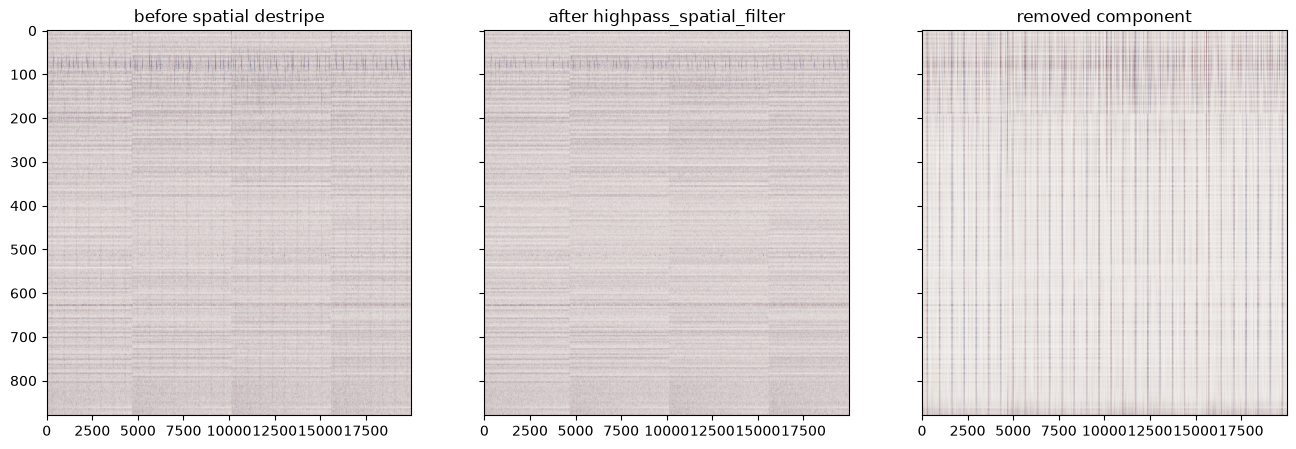

std before: 2.5019426
std after: 2.393559
removed abs percentiles: [0.3885958  1.46040706 2.53040698]


In [28]:
start_frame = int(5 * recording.get_sampling_frequency())
end_frame = start_frame + 20000

before = recording_hp.remove_channels(dead_channel_ids).get_traces(
    start_frame=start_frame,
    end_frame=end_frame,
    return_in_uV=False,
).T

after = recording_destriped.get_traces(
    start_frame=start_frame,
    end_frame=end_frame,
    return_in_uV=False,
).T

lim = np.percentile(np.abs(np.r_[before.ravel(), after.ravel()]), 99.5)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

axes[0].imshow(before, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim)
axes[0].set_title("before spatial destripe")

axes[1].imshow(after, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim)
axes[1].set_title("after highpass_spatial_filter")

diff_lim = np.percentile(np.abs(after - before), 99.5)
axes[2].imshow(after - before, aspect="auto", cmap="RdBu_r", vmin=-diff_lim, vmax=diff_lim)
axes[2].set_title("removed component")

plt.show()

print("std before:", np.std(before))
print("std after:", np.std(after))
print("removed abs percentiles:", np.percentile(np.abs(after - before), [50, 95, 99]))

In [ ]:
`si.common_reference`?

Signature:
si.common_reference(
    recording: spikeinterface.core.baserecording.BaseRecording,
    reference: Literal['global', 'single', 'local'] = 'global',
    operator: Literal['median', 'average'] = 'median',
    groups: list | None = None,
    ref_channel_ids: list | str | int | None = None,
    local_radius: tuple[float, float] = (30.0, 55.0),
    min_local_neighbors: int = 5,
    dtype: str | numpy.dtype | None = None,
)
Docstring:
Re-references the recording extractor traces. That is, the value of the traces are
shifted so the there is a new zero (reference).

The new reference can be estimated either by using a common median reference (CMR) or
a common average reference (CAR).

The new reference can be set three ways:
     * "global": the median/average of all channels is set as the new reference.
        In this case, the 'global' median/average is subtracted from all channels.
     * "single": In the simplest case, a single channel from the recording is set as the new refe

We still got some strips here goona fix them later

In [ ]:
from pathlib import Path
import torch
import spikeinterface.full as si

assert "recording_clean" in globals()
assert recording_clean.get_probe() is not None
assert torch.cuda.is_available()

job_kwargs = dict(n_jobs=8, chunk_duration="1s", progress_bar=True)

recording_for_motion = si.bandpass_filter(
    recording_clean,
    freq_min=300.0,
    freq_max=6000.0,
)

preset = "dredge"
folder = Path("motion_outputs") / "recording_clean_bandpass_dredge_cuda"

motion, motion_info = si.compute_motion(
    recording_for_motion,
    preset=preset,
    folder=folder,
    overwrite=True,
    output_motion_info=True,
    detect_kwargs=dict(
        detect_threshold=5.0,
        peak_sign="both",
    ),
    estimate_motion_kwargs=dict(device="cuda"),
    **job_kwargs,
)

print(motion)
print("run_times:", motion_info["run_times"])
print("n_peaks:", motion_info["peaks"].shape[0])


noise_level (workers: 8 processes spawn):   0%|          | 0/20 [00:00<?, ?it/s]

detect and localize (workers: 8 processes spawn):   0%|          | 0/1596 [00:00<?, ?it/s]

Cross correlation:   0%|          | 0/18 [00:00<?, ?it/s]

Solve:   0%|          | 0/17 [00:00<?, ?it/s]

Motion non-rigid - 18 spatial bins - interval 1.0s - 1 segments
run_times: {'detect_and_localize': 415.899046999999, 'estimate_motion': 12.814614599999913}
n_peaks: 781368


In [ ]:
'''
job_kwargs = dict(n_jobs=8, chunk_duration="1s", progress_bar=True)
si.set_global_job_kwargs(**job_kwargs)

noise_random_slices = dict(num_chunks_per_segment=20, chunk_duration="500ms")
noise_seeds = range(8)
noise_estimates = np.stack([
    si.get_noise_levels(
        recording_bandpass,
        
        return_in_uV=False,
        force_recompute=True,
        random_slices_kwargs={**noise_random_slices, "seed": seed},
        **job_kwargs,
    )
    for seed in noise_seeds
])
zero_noise_mask = np.any((noise_estimates <= 0) | ~np.isfinite(noise_estimates), axis=0)
zero_noise_channel_ids = recording_bandpass.channel_ids[zero_noise_mask]
print("zero-noise channel ids:", zero_noise_channel_ids)

if len(zero_noise_channel_ids):
    recording_bandpass_for_motion = recording_bandpass.remove_channels(zero_noise_channel_ids)
else:
    recording_bandpass_for_motion = recording_bandpass

motion_noise_estimates = np.stack([
    si.get_noise_levels(
        recording_bandpass_for_motion,
        return_in_uV=False,
        force_recompute=True,
        random_slices_kwargs={**noise_random_slices, "seed": seed},
        **job_kwargs,
    )
    for seed in noise_seeds
])
motion_noise_levels = np.mean(motion_noise_estimates, axis=0)
bad_motion_noise_mask = (motion_noise_levels <= 0) | ~np.isfinite(motion_noise_levels)
assert not np.any(bad_motion_noise_mask), recording_bandpass_for_motion.channel_ids[bad_motion_noise_mask]
recording_bandpass_for_motion.set_property("noise_level_mad_raw", motion_noise_levels)'''

In [31]:
preset = "dredge"

# Keep geometry explicit: current notebook uses hand-written 29 um geometry.
# Do not silently mix this with the .prb / paper 30 um geometry.
folder = Path("motion_outputs") / "2026-07-08_dredge_29um_handwritten"

reuse_existing_motion = True
overwrite_motion = False

if reuse_existing_motion and overwrite_motion:
    raise ValueError("Choose only one: reuse_existing_motion=True or overwrite_motion=True.")

cached_noise_levels = recording_clean.get_property("noise_level_mad_raw")
assert cached_noise_levels is not None, "Run the previous noise-estimation cell first."

bad_cached_noise_mask = (cached_noise_levels <= 0) | ~np.isfinite(cached_noise_levels)
assert not np.any(bad_cached_noise_mask), recording_clean.channel_ids[bad_cached_noise_mask]

if folder.exists() and reuse_existing_motion:
    motion_info = si.load_motion_info(folder)
    motion = motion_info["motion"]
    print(f"Loaded existing motion_info from: {folder}")

elif folder.exists() and not overwrite_motion:
    raise FileExistsError(
        f"{folder} already exists. "
        "Set reuse_existing_motion=True to load it, "
        "choose a new folder name, or set overwrite_motion=True to recompute."
    )

else:
    motion, motion_info = si.compute_motion(
        recording_clean,
        preset=preset,
        folder=folder,
        overwrite=overwrite_motion,
        output_motion_info=True,
        estimate_motion_kwargs=dict(device="cuda"),
        **job_kwargs,
    )
    print(f"Saved new motion_info to: {folder}")

AssertionError: Run the previous noise-estimation cell first.

Motion non-rigid - 18 spatial bins - interval 1.0s - 1 segments
run_times: {'detect_and_localize': 415.899046999999, 'estimate_motion': 12.814614599999913}
n_peaks: 781368


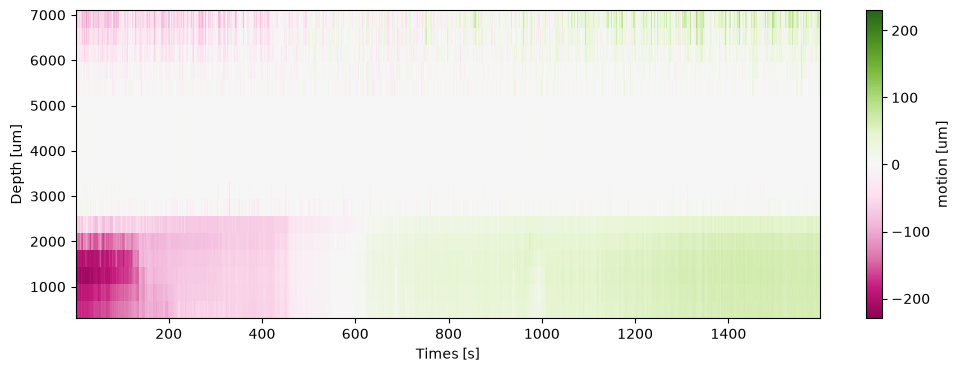

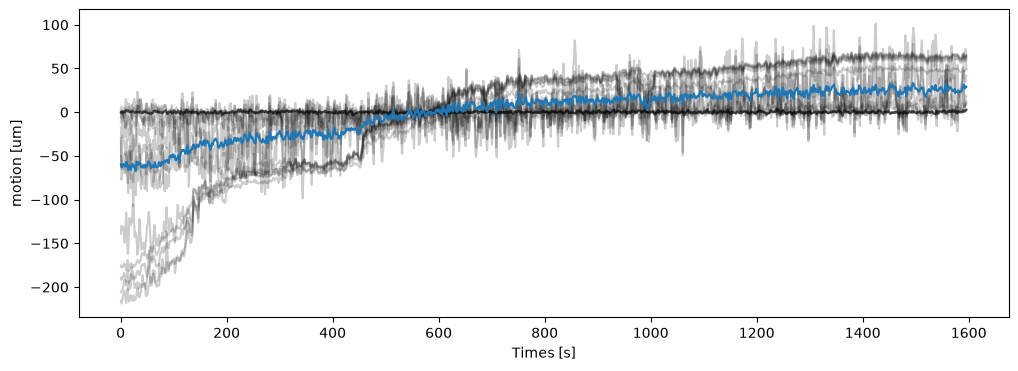

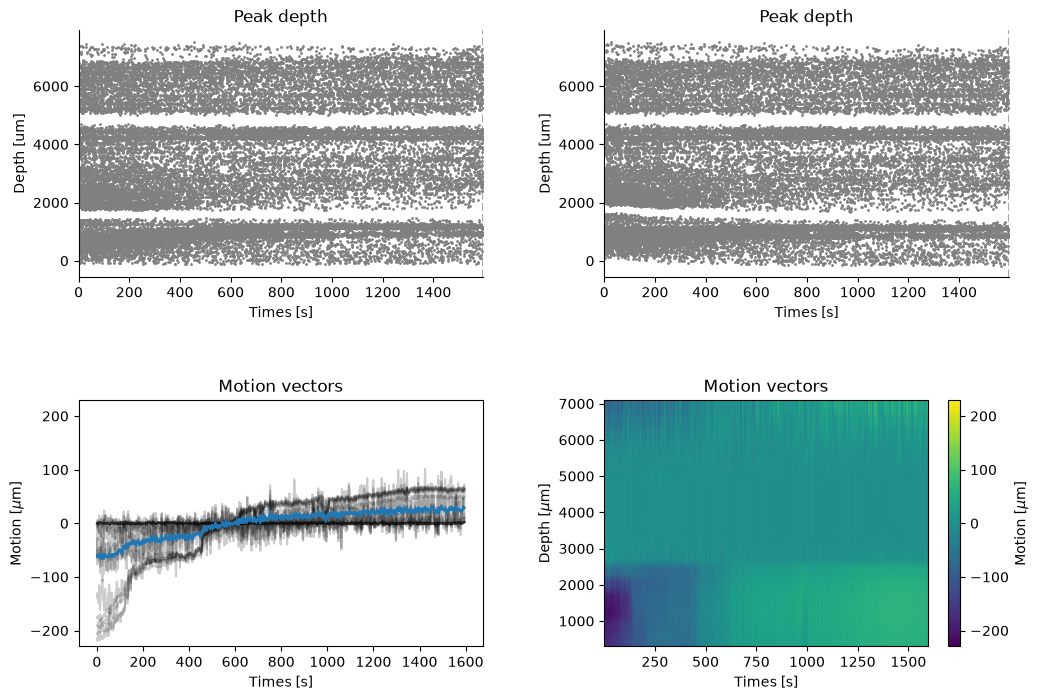

In [53]:
# Display DREDge/SI motion results using only SpikeInterface widgets.
folder = "./motion_tmp/"

if "motion_info" not in globals() or "motion" not in globals():
    motion_info = si.load_motion_info(folder)
    motion = motion_info["motion"]

assert motion is not None, "No motion object found. Re-run si.compute_motion(..., preset='dredge')."

print(motion)
print("run_times:", motion_info["run_times"])
print("n_peaks:", motion_info["peaks"].shape[0])

# Motion estimate: heatmap over time/depth and line view.
si.plot_motion(motion, mode="map", backend="matplotlib", figsize=(12, 4))
si.plot_motion(motion, mode="line", backend="matplotlib", figsize=(12, 4))

# Full SI summary: drift raster before correction, after correction, and motion vectors.
si.plot_motion_info(
    motion_info,
    recording=recording_for_motion,
    backend="matplotlib",
    scatter_decimate=20,
    color_amplitude=False,
    figsize=(12, 8),
)

# DARTsort full sorting

This section runs DARTsort as a full spike sorter using the bad-channel-cleaned recording.

In [ ]:
#Load motion info from previous DRedge run. Comment them if using new data.
from pathlib import Path
import spikeinterface.full as si

motion_folder = Path(r"D:\SPIHackerthon\spikeinterface\motion_outputs\recording_clean_bandpass_dredge_cuda")

motion_info = si.load_motion_info(motion_folder)
motion = motion_info["motion"]

print(motion)
print("n_peaks:", motion_info["peaks"].shape[0])
print("run_times:", motion_info["run_times"])

Motion non-rigid - 18 spatial bins - interval 1.0s - 1 segments
n_peaks: 781368
run_times: {'detect_and_localize': 415.899046999999, 'estimate_motion': 12.814614599999913}


In [18]:
import importlib.metadata

import dartsort
import torch

assert "recording_clean" in globals(), "Run the bad-channel removal cell before this DARTsort section."

dartsort_version = importlib.metadata.version("dartsort")
print("DARTsort:", dartsort_version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

assert torch.cuda.is_available(), "DARTsort is configured below with device='cuda', but CUDA is not available."

print(recording_clean)
print("channels:", recording_clean.get_num_channels())
print("sampling frequency:", recording_clean.get_sampling_frequency())
assert recording_clean.get_probe() is not None, "recording_clean needs a probe before running DARTsort."

DARTsort: 0.5.12
Torch: 2.11.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4090
ChannelSliceRecording: 880 channels - 20.0kHz - 1 segments - 31,912,000 samples 
                       1,595.60s (26.59 minutes) - float32 dtype - 104.62 GiB
channels: 880
sampling frequency: 20000.0


In [19]:
from pathlib import Path

dartsort_output_dir = Path("dartsort_outputs") / "2026-07-09_2_full_29um_handwritten_ibllikecmr"
dartsort_output_dir.parent.mkdir(parents=True, exist_ok=True)

run_dartsort = True
reuse_existing_dartsort = False
overwrite_dartsort = True

if reuse_existing_dartsort and overwrite_dartsort:
    raise ValueError("Choose only one: reuse_existing_dartsort=True or overwrite_dartsort=True.")

dartsort_cfg = dartsort.DARTsortUserConfig(
    preprocessing="ibllikecmr",
    device="cuda",
    do_motion_estimation=False,
    
)

dartsort_input_recording = recording_clean
# For a quick smoke test before the full run, uncomment the next two lines.
#smoke_test_duration_s = 60
#dartsort_input_recording = recording_clean.frame_slice(0, int(smoke_test_duration_s * recording_clean.get_sampling_frequency()))

if dartsort_output_dir.exists() and reuse_existing_dartsort:
    dartsort_sorting = dartsort.load(dartsort_output_dir)
    dartsort_motion = dartsort.try_load_motion_info(dartsort_output_dir)
    dartsort_result = {"sorting": dartsort_sorting, "motion": dartsort_motion}
    print(f"Loaded existing DARTsort output from: {dartsort_output_dir}")

elif dartsort_output_dir.exists() and not overwrite_dartsort:
    raise FileExistsError(
        f"{dartsort_output_dir} already exists. "
        "Set reuse_existing_dartsort=True to load it, "
        "choose a new folder name, or set overwrite_dartsort=True to recompute."
    )

elif run_dartsort:
    dartsort_result = dartsort.dartsort(
        dartsort_input_recording,
        dartsort_output_dir,
        cfg=dartsort_cfg,
        overwrite=overwrite_dartsort,
        si_motion=motion,
    )
    dartsort_sorting = dartsort_result["sorting"]
    dartsort_motion = dartsort_result.get("motion")
    print(f"Saved new DARTsort output to: {dartsort_output_dir}")

else:
    dartsort_result = None
    dartsort_sorting = None
    dartsort_motion = None
    print("Set run_dartsort=True to run DARTsort, or create the output folder and keep reuse_existing_dartsort=True to load it.")

if dartsort_sorting is not None:
    si_dartsort_sorting = dartsort_sorting.to_numpy_sorting()
    print(si_dartsort_sorting)
else:
    si_dartsort_sorting = None



noise_level (no parallelization):   0%|          | 0/100 [00:00<?, ?it/s]

Load initial denoiser fit data:cuda 1.5s/it [spk/it=%%%]:   0%|          | 0/1064 [00:00<?, ?it/s]

Got 923433 spikes, enough to stop early.


Epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]

: 

DARTsort output: D:\SPIHackerthon\spikeinterface\dartsort_outputs\2026-07-09_1_full_29um_handwritten_ibllikecmr
DARTsort units: 93
DARTsort spikes: 26178
NumpySorting: 93 units - 1 segments - 20.0kHz


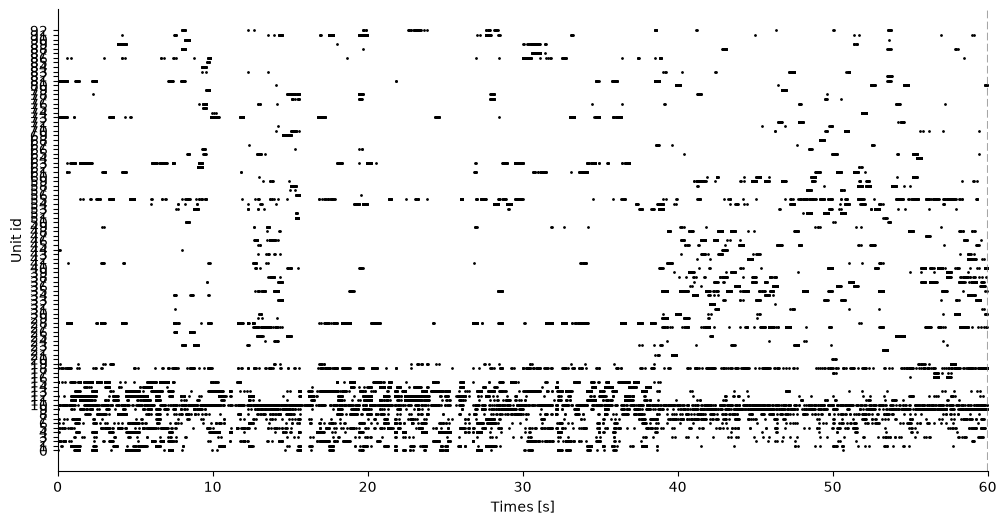

In [63]:
import spikeinterface.full as si
import matplotlib.pyplot as plt

assert "si_dartsort_sorting" in globals() and si_dartsort_sorting is not None

unit_ids = si_dartsort_sorting.get_unit_ids()
segment_index = 0

# smoke test 是 60 秒，所以这里按 DARTsort 输入 recording 来算更准确
sr = dartsort_input_recording.get_sampling_frequency()
duration_s = dartsort_input_recording.get_num_frames(segment_index=segment_index) / sr
raster_time_range = [0, min(60, duration_s)]

num_spikes = sum(
    si_dartsort_sorting.get_unit_spike_train(
        unit_id=unit_id,
        segment_index=segment_index,
    ).size
    for unit_id in unit_ids
)

print("DARTsort output:", dartsort_output_dir.resolve())
print("DARTsort units:", len(unit_ids))
print("DARTsort spikes:", num_spikes)
print(si_dartsort_sorting)

if len(unit_ids) == 0:
    print("DARTsort returned no units to plot.")
else:
    si.plot_rasters(
        si_dartsort_sorting,
        unit_ids=unit_ids,
        segment_indices=[segment_index],
        time_range=raster_time_range,
        backend="matplotlib",
        figsize=(12, 6),
    )
    plt.show()

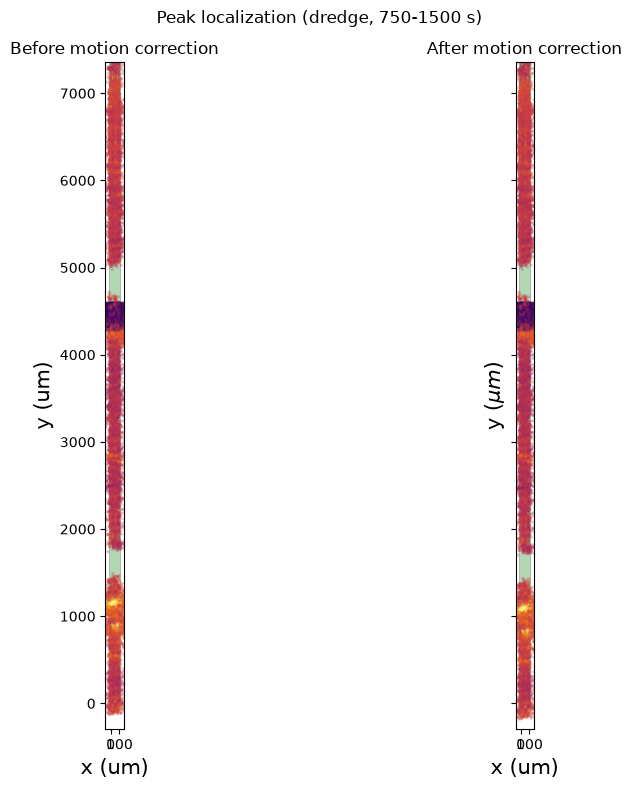

In [55]:
from spikeinterface.sortingcomponents.motion import correct_motion_on_peaks

recording_for_peak_plot = recording_clean

if "motion_info" not in globals() or "motion" not in globals():
    motion_info = si.load_motion_info(folder)
    motion = motion_info["motion"]

peaks = motion_info["peaks"]
peak_locations = motion_info["peak_locations"]
corrected_peak_locations = correct_motion_on_peaks(
    peaks,
    peak_locations,
    motion,
    recording_for_peak_plot,
)

segment_index = 0
sr = recording_for_peak_plot.get_sampling_frequency()
duration_s = recording_for_peak_plot.get_num_frames(segment_index=segment_index) / sr

time_lim0, time_lim1 = 750.0, min(1500.0, duration_s)
if time_lim1 <= time_lim0:
    time_lim0, time_lim1 = 0.0, duration_s

mask = (
    (peaks["sample_index"] >= int(sr * time_lim0))
    & (peaks["sample_index"] <= int(sr * time_lim1))
)
if "segment_index" in peaks.dtype.names:
    mask &= peaks["segment_index"] == segment_index

assert np.any(mask), f"No peaks found between {time_lim0:.1f}s and {time_lim1:.1f}s."

peak_slice = slice(None, None, 5)
amps = np.abs(peaks["amplitude"][mask][peak_slice])
amp_q95 = np.quantile(amps, 0.95)
amps_scaled = amps / amp_q95 if np.isfinite(amp_q95) and amp_q95 > 0 else amps
colors = plt.get_cmap("inferno")(np.clip(amps_scaled, 0, 1))
scatter_kwargs = dict(alpha=0.2, s=2, c=colors)

fig, axs = plt.subplots(ncols=2, figsize=(12, 8), sharey=True)

for ax, locs, title in zip(
    axs,
    [peak_locations, corrected_peak_locations],
    ["Before motion correction", "After motion correction"],
):
    si.plot_probe_map(recording_for_peak_plot, ax=ax)
    ax.scatter(locs["x"][mask][peak_slice], locs["y"][mask][peak_slice], **scatter_kwargs)
    ax.set_title(title)
    ax.set_xlabel("x (um)")

axs[0].set_ylabel("y (um)")

plot_y = np.concatenate([
    peak_locations["y"][mask][peak_slice],
    corrected_peak_locations["y"][mask][peak_slice],
])
y_low, y_high = np.nanpercentile(plot_y, [1, 99])
y_pad = max(25.0, 0.05 * (y_high - y_low))

for ax in axs:
    ax.set_ylim(y_low - y_pad, y_high + y_pad)

fig.suptitle(f"Peak localization ({preset}, {time_lim0:.0f}-{time_lim1:.0f} s)")
fig.tight_layout()

In [56]:
# Zoom into peak-dense depth bands.
# This uses the same time window and motion-corrected peak locations from the previous cell.

cluster_bin_um = 60.0
zoom_half_height_um = 180.0
min_cluster_separation_um = 250.0
n_zoom_clusters = 5
plot_decimate = 2

y_for_density = peak_locations["y"][mask]
y_for_density = y_for_density[np.isfinite(y_for_density)]

y_min, y_max = np.nanpercentile(y_for_density, [0.5, 99.5])
bins = np.arange(y_min, y_max + cluster_bin_um, cluster_bin_um)

counts, edges = np.histogram(y_for_density, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

candidate_order = np.argsort(counts)[::-1]

cluster_centers = []
for candidate_index in candidate_order:
    if counts[candidate_index] == 0:
        break

    candidate_center = centers[candidate_index]
    far_enough = all(
        abs(candidate_center - existing_center) >= min_cluster_separation_um
        for existing_center in cluster_centers
    )

    if far_enough:
        cluster_centers.append(candidate_center)

    if len(cluster_centers) >= n_zoom_clusters:
        break

cluster_centers = np.array(sorted(cluster_centers))

print("Zoom cluster centers y (um):", np.round(cluster_centers, 1))

Zoom cluster centers y (um): [ 823.1 1123.1 4243.1 5683.1 6763.1]


y=823 um, n=15812, median dy=-40.06 um, p5/p95 dy=-64.19/-24.49 um
y=1123 um, n=48431, median dy=-52.51 um, p5/p95 dy=-66.42/-36.59 um
y=4243 um, n=15404, median dy=0.08 um, p5/p95 dy=-2.02/1.63 um
y=5683 um, n=6943, median dy=-2.33 um, p5/p95 dy=-16.60/7.11 um
y=6763 um, n=6973, median dy=-19.60 um, p5/p95 dy=-58.56/11.62 um


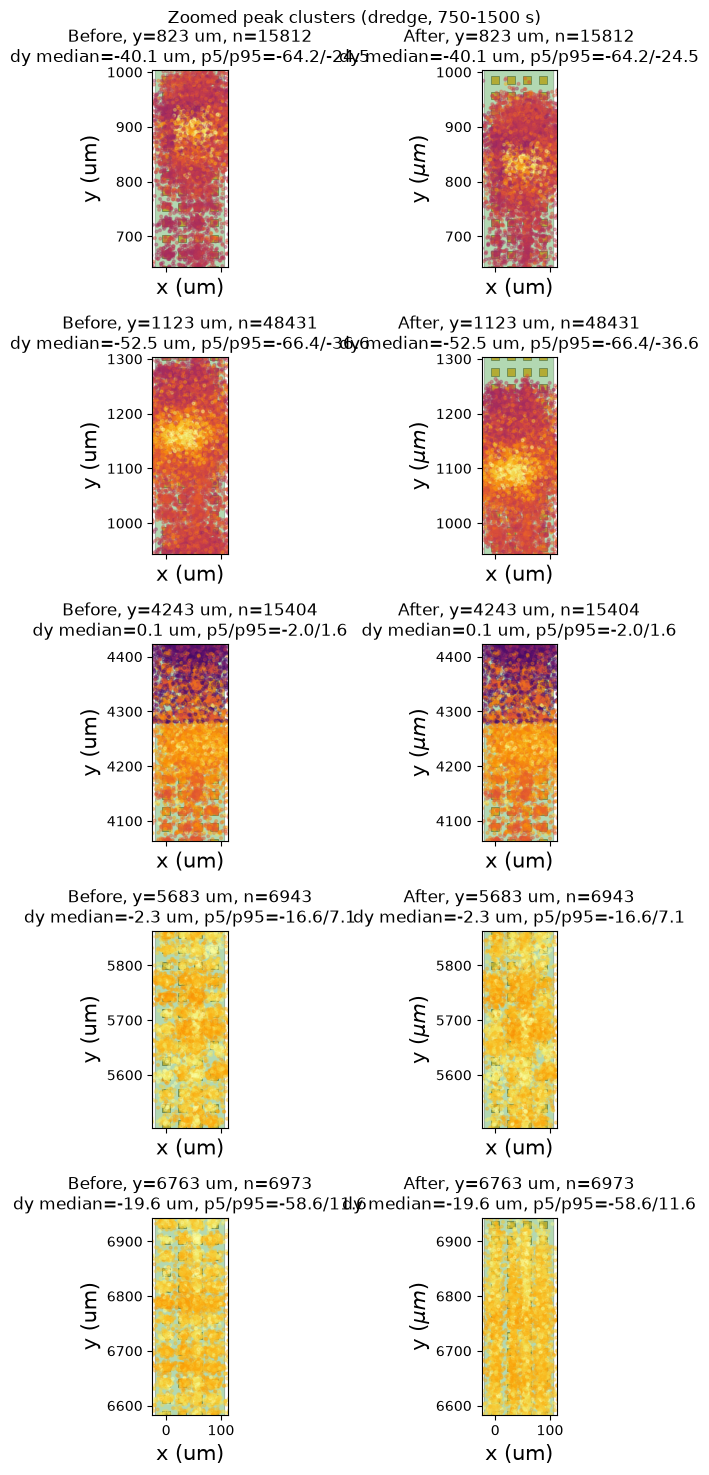

In [57]:
channel_locations = recording_for_peak_plot.get_channel_locations()
x_low, x_high = np.nanmin(channel_locations[:, 0]) - 25, np.nanmax(channel_locations[:, 0]) + 25

base_mask = mask.copy()

fig, axs = plt.subplots(
    nrows=len(cluster_centers),
    ncols=2,
    figsize=(8, 3.0 * len(cluster_centers)),
    sharex=True,
)

if len(cluster_centers) == 1:
    axs = np.array([axs])

for row_index, y_center in enumerate(cluster_centers):
    y_low = y_center - zoom_half_height_um
    y_high = y_center + zoom_half_height_um

    same_peak_mask = (
        base_mask
        & (peak_locations["y"] >= y_low)
        & (peak_locations["y"] <= y_high)
    )

    plot_indices = np.flatnonzero(same_peak_mask)[::plot_decimate]
    dy = corrected_peak_locations["y"][plot_indices] - peak_locations["y"][plot_indices]
    median_dy = np.nanmedian(dy) if dy.size else np.nan
    dy_p5, dy_p95 = np.nanpercentile(dy, [5, 95]) if dy.size else (np.nan, np.nan)

    print(
        f"y={y_center:.0f} um, n={plot_indices.size}, "
        f"median dy={median_dy:.2f} um, "
        f"p5/p95 dy={dy_p5:.2f}/{dy_p95:.2f} um"
    )

    amps = np.abs(peaks["amplitude"][plot_indices])
    amp_q95 = np.quantile(amps, 0.95) if amps.size else np.nan
    amps_scaled = amps / amp_q95 if np.isfinite(amp_q95) and amp_q95 > 0 else amps
    colors = plt.get_cmap("inferno")(np.clip(amps_scaled, 0, 1))

    for ax, locs, title in zip(
        axs[row_index],
        [peak_locations, corrected_peak_locations],
        ["Before", "After"],
    ):
        si.plot_probe_map(recording_for_peak_plot, ax=ax)
        ax.scatter(
            locs["x"][plot_indices],
            locs["y"][plot_indices],
            s=4,
            alpha=0.35,
            c=colors,
        )

        ax.set_xlim(x_low, x_high)
        ax.set_ylim(y_low, y_high)
        ax.set_title(
            f"{title}, y={y_center:.0f} um, n={plot_indices.size}\n"
            f"dy median={median_dy:.1f} um, p5/p95={dy_p5:.1f}/{dy_p95:.1f}"
        )
        ax.set_xlabel("x (um)")

    axs[row_index, 0].set_ylabel("y (um)")

fig.suptitle(f"Zoomed peak clusters ({preset}, {time_lim0:.0f}-{time_lim1:.0f} s)")
fig.tight_layout()